In [2]:
# Import necessary libraries
import os   # jesus christ i have been losing sanity
os.environ["R_HOME"] = r"C:\\Program Files\\R\\R-4.4.1" 
os.environ["PATH"] = r"C:\\Program Files\\R\\R-4.4.1\\bin\\x64" + ";" + os.environ["R_HOME"] 
import pandas as pd
import numpy as np
import json
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
import time

In [2]:
# Load the dataset
def load_data(file_path):
    """
    Load the dataset from a specified CSV or Excel file.
    """
    if file_path.endswith('.csv'):
        # Read CSV with appropriate settings
        data = pd.read_csv(file_path, header=0, dtype=str)  # Load all data as string
    else:
        # For Excel files, you might not need to set dtype
        data = pd.read_excel(file_path)

    # Ensure no categorical transformation by keeping all as string initially
    data = data.astype(str)

    return data

In [3]:
def run_mulset(data):
    print("Input DataFrame shape:", data.shape)
    print("Input DataFrame columns:", data.columns)
    print("Input DataFrame head:\n", data.head())

    # Import the mulset R library
    mulset = importr('mulset')

    # Convert the DataFrame to an R DataFrame
    r_data = pandas2ri.py2rpy(data)

    # Define parameters for mulset
    exclude = ['donor_id', 'outcome']
    include = ["samples", "samples_count"]
    max_intersections = 250

    # Run the mulset function to generate subsets
    mulset_results = mulset.mulset(r_data, exclude=exclude, include=include, maxIntersections=max_intersections)

    # Convert the R results back to a Pandas DataFrame
    result_list = []
    
    # Iterate through the results
    for idx in range(len(mulset_results)):
        result = mulset_results.rx2(idx + 1)  # Access the individual result in the list (R index starts at 1)

        # Debugging: print the names of the elements in the result
        print(f"Result {idx + 1} names:", result.names)
        
        # Extract the fields
        result_dict = {
            'features_hash': result.rx2('features_hash')[0],
            'feature_count': result.rx2('feature_count')[0],
            'features': ', '.join(result.rx2('features')),
            'samples': ', '.join(map(str, result.rx2('samples'))) if 'samples' in result.names else None,
            'samples_count': result.rx2('samples_count')[0] if 'samples_count' in result.names else None,
            'datapoints': result.rx2('datapoints')[0] if 'datapoints' in result.names else None
        }
        result_list.append(result_dict)

    subsets = pd.DataFrame(result_list)

    # Filter datasets based on the number of features and samples
    filtered_subsets = subsets[(subsets['feature_count'] >= 5) & (subsets['samples_count'] >= 15)]

    return filtered_subsets

# Test function to run mulset with test data
def test_mulset():
    test_data = pd.DataFrame({
        'outcome': ['low', 'high', 'low', 'high'],
        'age': [77, 61, 58, 90],
        'gender': ['male', 'female', 'female', 'male'],
        'Feature 7': [None, 7, 91, 20],
        'Feature 3': [0, None, 10, 0],
        'Feature 4': [28, 28, None, 5],
        'Feature 5': [5, 5, 18, None]
    })

    result = run_mulset(test_data)
    print(result)


In [4]:
# Preprocess the data
def preprocess_data(data):
    """
    Preprocess the dataset by handling missing values, converting categorical variables,
    and normalizing features if necessary.
    """
    # Check for missing values
    print("Missing values before preprocessing:\n", data.isnull().sum())

    original_columns = data.shape[1]
    
    # Use intersections to fill missing values or drop features
    # Here you would apply your strategy based on shared features identified by mulset
    data.dropna(axis=1, inplace=True)  # Example strategy: drop columns with missing values
   
    current_columns = data.shape[1]
    print(f"Dropped {original_columns - current_columns} columns with missing values.")


    if 'outcome' in data.columns:
        data['outcome'] = data['outcome'].map({'low': 0, 'high': 1})

    # Convert categorical columns to numeric if necessary
    data = pd.get_dummies(data, columns=['type'], drop_first=True)

    # Split features and target variable
    X = data.drop(columns=['Donor ID', 'outcome'])
    y = data['outcome']

    # Normalize the features (if needed)
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    # or log?
    X = scaler.fit_transform(X)

    # print our data, X and y
    print("Preprocessed DataFrame shape:", data.shape)
    print("Preprocessed DataFrame columns:", data.columns)
    print("Preprocessed DataFrame head:\n", data.tail())
    print("X shape:", X.shape)
    print("y shape:", y.shape)
    return X, y


In [5]:
# Train and validate the models using cross-validation
def train_validate_models(X, y):
    models = {
        "Random Forest": RandomForestClassifier(random_state=1337),
        "Support Vector Classifier": SVC(random_state=1337),
        "Logistic Regression": LogisticRegression(random_state=1337),
        "Decision Tree": DecisionTreeClassifier(random_state=1337)
    }

    cv_results = {}
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model in models.items():
        print(f"\nValidating {model_name} with cross-validation...")
        cv_scores = cross_val_score(model, X, y, cv=skf)
        cv_results[model_name] = cv_scores
        print(f"{model_name} Cross-Validation Scores: {cv_scores}")
        print(f"{model_name} Average CV Score: {cv_scores.mean()}")

    return models, cv_results


In [6]:
def perform_grid_search(models, param_grids, X, y):
    best_models = {}
    best_params = {}
    for model_name, model in models.items():
        print(f"\nPerforming Grid Search for {model_name}...")
        grid_search = GridSearchCV(model, param_grids[model_name], cv=5, n_jobs=-1, verbose=1)
        grid_search.fit(X, y)
        best_models[model_name] = grid_search.best_estimator_
        best_params[model_name] = grid_search.best_params_
        print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    return best_models, best_params


In [7]:
# Train the models on the entire training set
def train_models(models, X_train, y_train, best_params):
    trained_models = {}
    for model_name, model in models.items():
        print(f"\nTraining {model_name} with best parameters on the training set...")
        model.set_params(**best_params[model_name])
        model.fit(X_train, y_train)
        trained_models[model_name] = model
    return trained_models


In [8]:
# Evaluate models on the test set
def evaluate_models(models, X_test, y_test):
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        print(f"\nEvaluation for {model_name}:")
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        plt.figure(figsize=(10, 6))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
        plt.title(f'Confusion Matrix for {model_name}')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()
        if len(set(y_test)) > 1:
            roc_auc = roc_auc_score(y_test, y_pred)
            print(f"ROC-AUC Score for {model_name}: {roc_auc}")
            fpr, tpr, _ = roc_curve(y_test, y_pred)
            plt.figure()
            plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
            plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel('False Positive Rate')
            plt.ylabel('True Positive Rate')
            plt.title(f'Receiver Operating Characteristic for {model_name}')
            plt.legend(loc='lower right')
            plt.show()
        else:
            print(f"ROC-AUC Score for {model_name}: Not applicable (only one class present)")



In [9]:
def mainWithoutMulset(file_path):
    data = load_data(file_path)
    X, y = preprocess_data(data)
    # print the shape of X and y
    
    X, y = SMOTE(random_state=1337).fit_resample(X, y)
    # # here, undersample too
    # rus = RandomUnderSampler(random_state=1337)
    # X, y = rus.fit_resample(X, y)

    # use ADASYN instead of SMOTE
    # X, y = ADASYN(random_state=1337).fit_resample(X, y)

    print("Shape of X:", X.shape)
    print("Shape of y:", y.shape)
    if X.size > 0:
        # Split the data into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1337)

        # Train and validate models using cross-validation
        models, cv_results = train_validate_models(X_train, y_train)

        param_grids = {
            "Random Forest": {
                "n_estimators": [100, 200, 300],
                "max_depth": [None, 10, 20, 30],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": [None, 'sqrt', 'log2']
            },
            "Support Vector Classifier": {
                "C": [0.1, 1, 10, 100],
                "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
                "gamma": ['scale', 'auto']
            },
            "Logistic Regression": {
                "C": [0.1, 1, 10, 100],
                "solver": ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
                "penalty": ['l2']
            },
            "Decision Tree": {
                "max_depth": [None, 10, 20, 30],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": [None, 'sqrt', 'log2'],
                "criterion": ['gini', 'entropy']
            }
        }

        # ## Train the models on the entire training set
        # #trained_models = train_models(models, X_train, y_train)

        # trained_models = perform_grid_search(models, param_grids, X_train, y_train, X_test, y_test)

        # # Evaluate the models on the test set
        # evaluate_models(trained_models, X_test, y_test)
        models, cv_results = train_validate_models(X_train, y_train)
        best_models, best_params = perform_grid_search(models, param_grids, X_train, y_train)
        #trained_models = train_models(models, X_train, y_train, best_params)
        evaluate_models(best_models, X_test, y_test)
    else:
        print("No valid subsets generated from the mulset function.")


Constructed dataset path: datasets/dataset 36.xlsx
Missing values before preprocessing:
 Donor ID                0
outcome                 0
B cells                 0
CD161- CD45RA+ Tregs    0
CD161+ CD45RA- Tregs    0
                       ..
T cells                 0
TNFA                    0
transitional B cells    0
Tregs                   0
type                    0
Length: 106, dtype: int64
Dropped 0 columns with missing values.
Preprocessed DataFrame shape: (40, 106)
Preprocessed DataFrame columns: Index(['Donor ID', 'outcome', 'B cells', 'CD161- CD45RA+ Tregs',
       'CD161+ CD45RA- Tregs', 'CD161+ CD45RA+ Tregs', 'CD161+ CD4+ T cells',
       'CD161+ CD8+ T cells', 'CD161+ NK cells', 'CD16+ monocytes',
       ...
       'naive CD4+ T cells', 'naive CD8+ T cells', 'NK cells', 'NKT cells',
       'plasmablasts', 'T cells', 'TNFA', 'transitional B cells', 'Tregs',
       'type_training'],
      dtype='object', length=106)
Preprocessed DataFrame head:
    Donor ID  outcome B cel

c:\Users\Tibuman\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Tibuman\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Tibuman\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Tibuman\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Tibuman\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi

Random Forest Cross-Validation Scores: [0.85714286 0.57142857 0.71428571 0.66666667 0.83333333]
Random Forest Average CV Score: 0.7285714285714285

Validating Support Vector Classifier with cross-validation...
Support Vector Classifier Cross-Validation Scores: [0.85714286 0.85714286 1.         0.66666667 0.83333333]
Support Vector Classifier Average CV Score: 0.8428571428571429

Validating Logistic Regression with cross-validation...
Logistic Regression Cross-Validation Scores: [0.71428571 0.85714286 0.71428571 0.83333333 1.        ]
Logistic Regression Average CV Score: 0.8238095238095238

Validating Decision Tree with cross-validation...
Decision Tree Cross-Validation Scores: [0.71428571 0.71428571 0.57142857 0.66666667 0.66666667]
Decision Tree Average CV Score: 0.6666666666666666

Validating Random Forest with cross-validation...
Random Forest Cross-Validation Scores: [0.85714286 0.57142857 0.71428571 0.66666667 0.83333333]
Random Forest Average CV Score: 0.7285714285714285

Valida

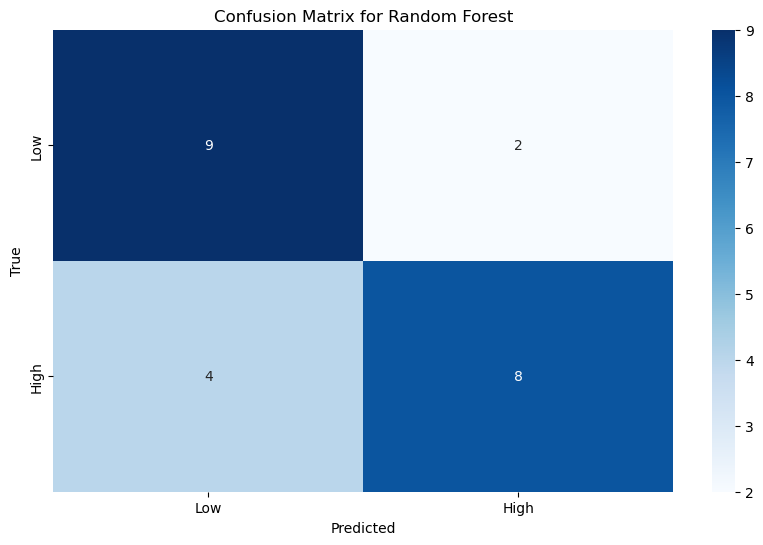

ROC-AUC Score for Random Forest: 0.7424242424242422


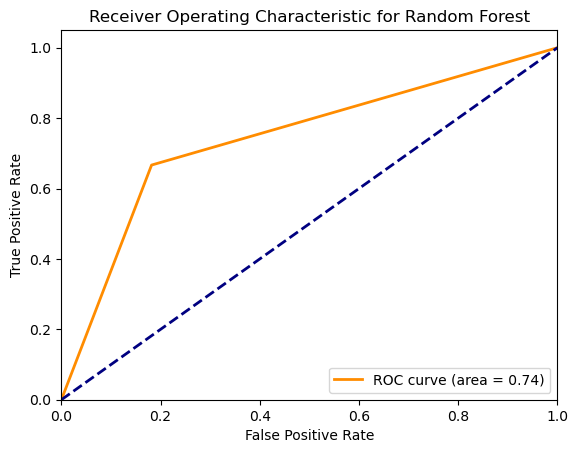


Evaluation for Support Vector Classifier:
Accuracy: 0.8260869565217391
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.83      0.83      0.83        12

    accuracy                           0.83        23
   macro avg       0.83      0.83      0.83        23
weighted avg       0.83      0.83      0.83        23

Confusion Matrix:
 [[ 9  2]
 [ 2 10]]


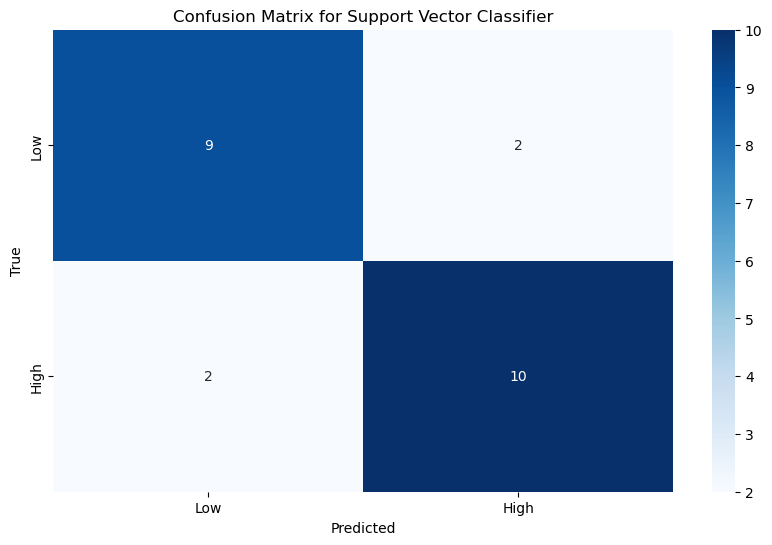

ROC-AUC Score for Support Vector Classifier: 0.8257575757575758


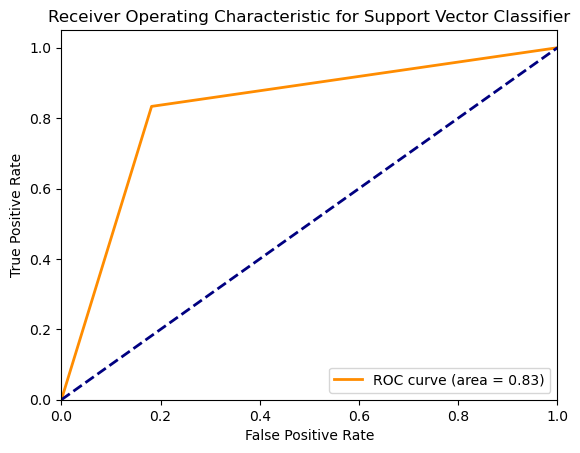


Evaluation for Logistic Regression:
Accuracy: 0.8695652173913043
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.85      0.92      0.88        12

    accuracy                           0.87        23
   macro avg       0.87      0.87      0.87        23
weighted avg       0.87      0.87      0.87        23

Confusion Matrix:
 [[ 9  2]
 [ 1 11]]


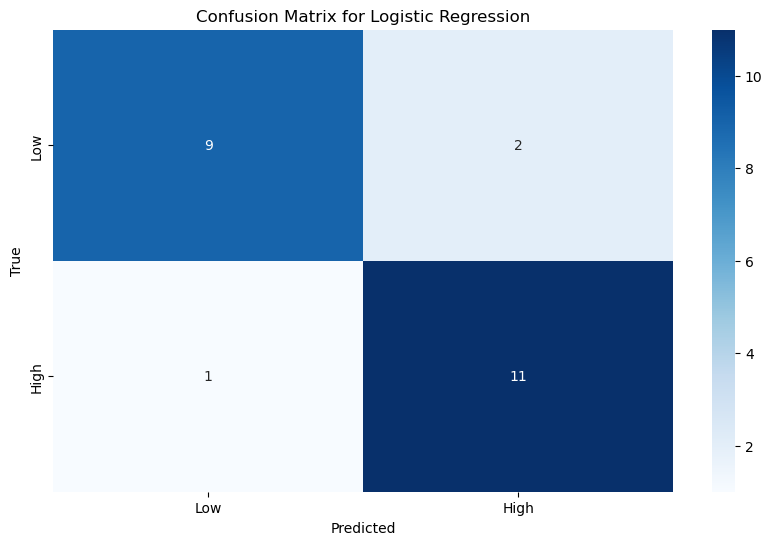

ROC-AUC Score for Logistic Regression: 0.8674242424242423


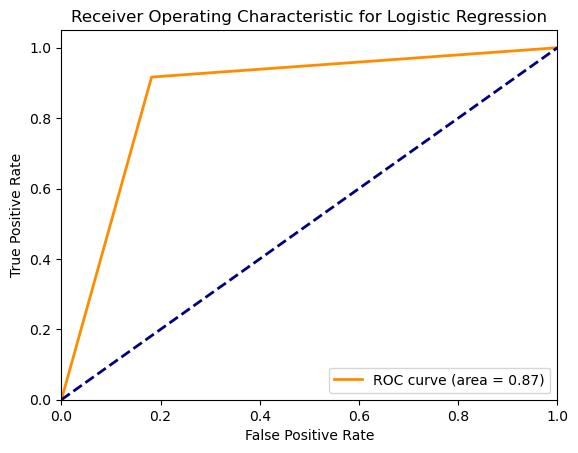


Evaluation for Decision Tree:
Accuracy: 0.7391304347826086
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.82      0.75        11
           1       0.80      0.67      0.73        12

    accuracy                           0.74        23
   macro avg       0.75      0.74      0.74        23
weighted avg       0.75      0.74      0.74        23

Confusion Matrix:
 [[9 2]
 [4 8]]


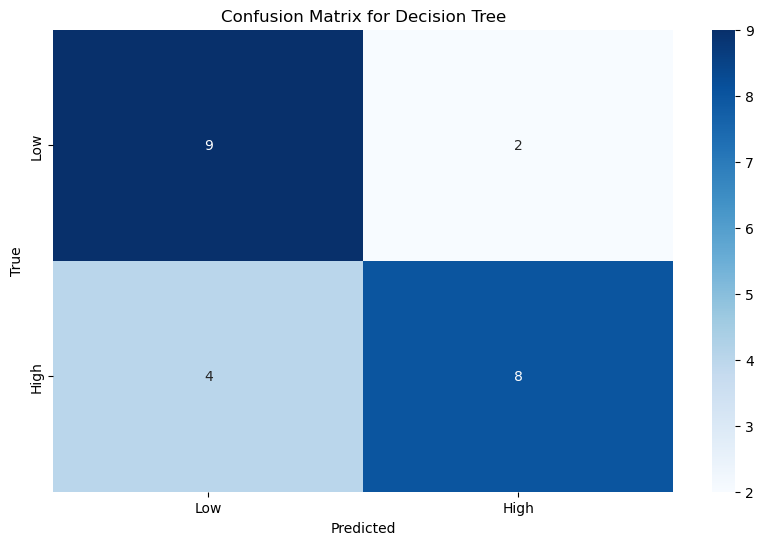

ROC-AUC Score for Decision Tree: 0.7424242424242422


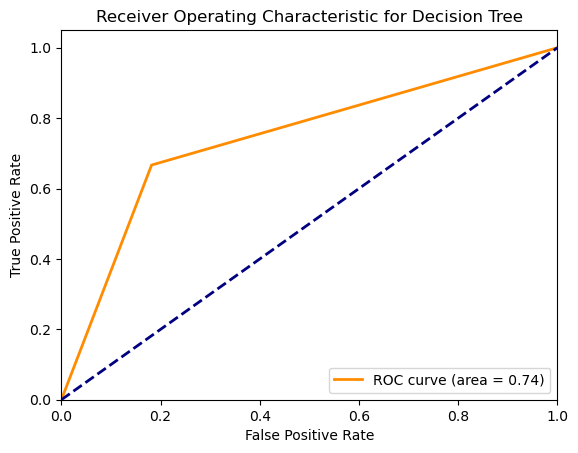

In [10]:
# Run the analysis
if __name__ == "__main__":
    pandas2ri.activate()
    # # Specify the path top your dataset
    # dataset_path = 'some data csv.csv'  # Change this to your dataset path
    # # main(dataset_path)

    # # just test mulset
    # data = load_data(dataset_path)
    # subsets = run_mulset(data)
    # print(subsets)
    # #test_mulset()
    # flow()

    # open "dataset 13.csv", drop last column (which is "training"/"testing"), separate into X and y, run the models
    dataset_path = "datasets/dataset 36.xlsx"
    #dir = os.path.dirname(__file__)
    #dataset_path = os.path.join(dir, dataset_path)

    print(f"Constructed dataset path: {dataset_path}")
    dataset_path = "datasets\dataset 36.xlsx"
    mainWithoutMulset(dataset_path)
    
    #if not os.path.isfile(dataset_path):
    #    print(f"File not found: {dataset_path}")
    #else:
    #    mainWithoutMulset(dataset_path)


In [10]:
import pyarrow.feather as feather

# Using SIMON datasets

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def preprocess_simon_data(data):
    """
    Preprocess the SIMON dataset for model training and testing.
    - Maps 'outcome' to 0 (low) and 1 (high).
    - Normalizes numerical features.
    - Splits features (X) and target variable (y).
    
    Parameters:
        data (pd.DataFrame): The raw dataset.

    Returns:
        X (np.ndarray): Normalized feature matrix.
        y (np.ndarray): Target vector (binary).
    """
    print("Original data shape:", data.shape)
    
    # Map 'outcome' to binary values
    if 'outcome' in data.columns:
        data['outcome'] = data['outcome'].map({'low': 0, 'high': 1})
    else:
        raise ValueError("The dataset must contain an 'outcome' column.")

    # Ensure no missing values in the dataset
    if data.isnull().any().any():
        print("Missing values detected, filling with median...")
        data.fillna(data.median(), inplace=True)

    # Separate features and target
    X = data.drop(columns=['outcome'])
    y = data['outcome']

    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("Preprocessed data shape: X =", X_scaled.shape, ", y =", y.shape)
    
    return X_scaled, y.values


def testSimonData(dataset_number=1):
    # use the parameter as the dataset folder number
    base_path = f"datasets\SIMON-data\{dataset_number}"
    json_info_path = f"{base_path}\json_info.feather"
    data_training_path = f"{base_path}\data_training.feather"
    data_testing_path = f"{base_path}\data_testing.feather"
    results_path = f"{base_path}\results.feather"

    files = {
        'json_info': json_info_path,
        'data_testing': data_testing_path,
        'data_training': data_training_path,
        'results': results_path
    }

    # Check if all files exist
    for file_type, file_path in files.items():
        if not os.path.isfile(file_path):
            print(f"File not found: {file_path}")
        else:
            try:
                # Read the Feather file
                table = feather.read_table(file_path)
                data = table.to_pandas()  # Convert to Pandas DataFrame

                # Print the first few rows of each file
                print(f"\n--- {file_type} ---")
                print(data.head())  # Display top rows
            except Exception as e:
                print(f"Error reading {file_type} file: {e}")


def testReadingFeather():
    # Read the Feather file
    table = feather.read_table("datasets\\SIMON-data\\8\\data_training.feather")
    data = table.to_pandas()  # Convert to Pandas DataFrame

    # use preproessData
    X, y = preprocess_simon_data(data)
    # print the shape of X and y
    print("Shape of X:", X.shape)
    print("Shape of y:", y.shape)

    # print if X contains NaN
    print("NaN in X:", np.isnan(X).any())



testSimonData(35)
testReadingFeather()




--- json_info ---
   feature_count                                                sql  \
0             99  B_cells','CD4_pos_CD27_pos_T_cells','CD4_pos_C...   

                      features_hash  donors_count data_source  
0  722aefabc8bd219ce164a0b5abfe9af5           105     initial  

--- data_testing ---
  outcome  B_cells  CD161_neg_CD45RA_pos_Tregs  CD161_pos_CD45RA_neg_Tregs  \
0    high     41.3                        16.6                        6.02   
1     low     30.2                        22.1                        4.99   
2     low     36.0                        32.6                        6.12   
3    high     42.2                        27.9                        4.03   
4     low     53.8                        15.0                        4.37   

   CD161_pos_CD45RA_pos_Tregs  CD161_pos_CD4_pos_T_cells  \
0                        0.72                      12.70   
1                        1.54                       9.37   
2                        1.74          

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler



def preprocess(X_train, X_test, y_train, y_test, impute_strategy = 'knn', transformation = 'log', resample_strategy = 'adasyn', scaler = 'standard'):
    # Returns arrays, must be converted to DataFrames!

    if impute_strategy == 'knn' or impute_strategy == 'KNN':
        # Simple (mean) or KNN Imputation
        imputer = KNNImputer(n_neighbors=5)
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
    elif impute_strategy == 'mean' or impute_strategy == 'simple':
        imputer = SimpleImputer(strategy='mean')
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
    elif impute_strategy == 'None' or impute_strategy == 'none':
        X_train_imputed = X_train
        X_test_imputed = X_test

    # Treat zeroes
    X_train_imputed[X_train_imputed == 0] = 1e-5
    X_test_imputed[X_test_imputed == 0] = 1e-5

    X_train = X_train_imputed
    X_test = X_test_imputed

    if transformation == 'log' or transformation == 'Log':
        # Ensure all values are positive by shifting data
        shift_constant = abs(X_train.min().min()) + 1  # Shift to make all values positive
        X_train_shifted = X_train + shift_constant
        X_test_shifted = X_test + shift_constant

        # Apply log transformation
        X_train_transformed = np.log1p(X_train_shifted)
        X_test_transformed = np.log1p(X_test_shifted)

    elif transformation == 'Yeo-Johnson' or transformation == 'yeo-johnson':
        transformer = PowerTransformer(method='yeo-johnson')
        X_train_transformed = transformer.fit_transform(X_train)
        X_test_transformed = transformer.transform(X_test)
    elif transformation == 'None' or transformation == 'none':
        X_train_transformed = X_train
        X_test_transformed = X_test

    X_train = X_train_transformed
    X_test = X_test_transformed

    if resample_strategy == 'ADASYN' or resample_strategy == 'adasyn':
        X_train, y_train = ADASYN(random_state=1337).fit_resample(X_train, y_train)

    elif resample_strategy == 'SMOTE' or resample_strategy == 'smote':
        X_train, y_train = SMOTE(random_state=1337).fit_resample(X_train, y_train)
    elif resample_strategy == 'None' or resample_strategy == 'none':
        # No resampling, do nothing
        pass
            

    if scaler == 'None' or scaler == 'none':
        return X_train, X_test, y_train, y_test
    
    
    if scaler == 'standard' or scaler == 'Standard':
        scaler = StandardScaler()
    elif scaler == 'minmax' or scaler == 'MinMax':
        scaler = MinMaxScaler()
    elif scaler == 'robust' or scaler == 'Robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Invalid scaler: {scaler}")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test



def process_single_dataset(data_training, data_testing, models):
    """
    Process a single dataset: split, train, evaluate, and filter models.
    Returns the best model and its performance metrics.
    """
    results = []
    
    
    # Map 'outcome' to binary (0: low, 1: high)
    data_training['outcome'] = data_training['outcome'].map({'low': 0, 'high': 1})
    data_testing['outcome'] = data_testing['outcome'].map({'low': 0, 'high': 1})

    if data_training.isnull().any().any():
        print("Missing values detected, filling with median...")
        data_training.fillna(data_training.median(), inplace=True)

    # Split training and test data
    X_train, y_train = data_training.drop(columns=['outcome']), data_training['outcome']
    X_test, y_test = data_testing.drop(columns=['outcome']), data_testing['outcome']

    # Filter datasets with fewer than 10 subjects in the test set
    if len(y_test) < 10:
        print("Dataset skipped due to insufficient test samples (<10).")
        return None

    X_train, X_test, y_train, y_test = preprocess(X_train, X_test, y_train, y_test, transformation='Log')

    # Convert back to DataFrame for compatibility
    X_train = pd.DataFrame(X_train, columns=data_training.drop(columns=['outcome']).columns)
    X_test = pd.DataFrame(X_test, columns=data_testing.drop(columns=['outcome']).columns)


    # Train and evaluate models
    for model_name, model in models.items():
        print(f"\nTraining {model_name}...")
        
        # Perform cross-validation
        # SIMON paper suggests 10
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        auc_scores = []
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            y_val_pred = model.predict_proba(X_train.iloc[val_idx])[:, 1]
            auc = roc_auc_score(y_train.iloc[val_idx], y_val_pred)
            auc_scores.append(auc)

        # Train on the entire training set
        model.fit(X_train, y_train)

        # Evaluate on test data
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        y_test_pred = model.predict(X_test)
        test_auc = roc_auc_score(y_test, y_test_pred_proba)
        specificity, sensitivity = calculate_specificity_sensitivity(y_test, y_test_pred)

        # Filter poorly performing models
        if test_auc <= 0.5 or (specificity < 0.5 and sensitivity < 0.5):
            print(f"{model_name} discarded due to poor performance (AUROC={test_auc:.2f}).")
            continue

        # Save results
        results.append({
            'model': model_name,
            'test_auc': test_auc,
            'specificity': specificity,
            'sensitivity': sensitivity,
            'conf_matrix': confusion_matrix(y_test, y_test_pred),
            'report': classification_report(y_test, y_test_pred, output_dict=True)
        })

    # Return the best model by AUROC
    if results:
        best_result = max(results, key=lambda x: x['test_auc'])
        print(f"Best model: {best_result['model']} with AUROC={best_result['test_auc']:.2f}")
        return best_result
    else:
        print("No suitable models for this dataset.")
        return None


def calculate_specificity_sensitivity(y_true, y_pred):
    """
    Calculate specificity and sensitivity from confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    return specificity, sensitivity


def process_all_datasets(base_path, models, impute_strategy = 'knn', transformation = 'log', resample_strategy = 'adasyn', scaler = 'standard'):
    """
    Process all datasets in the SIMON directory.
    """
    datasets = []
    # get the existing datasets by checking the existing directories

    for dataset_number in range(1, 206):  # Assuming 34 datasets
        # if file does not exist, skip
        if not os.path.exists(os.path.join(base_path, str(dataset_number))):
            print(f"Dataset {dataset_number} not found.")
            continue
        try:
            # Load data
            dataset_path = os.path.join(base_path, str(dataset_number))
            data_training = feather.read_table(os.path.join(dataset_path, 'data_training.feather')).to_pandas()
            data_testing = feather.read_table(os.path.join(dataset_path, 'data_testing.feather')).to_pandas()

            print(f"Processing Dataset {dataset_number}...")
            best_model_result = process_single_dataset_optimization(data_training, data_testing, models, transformation, resample_strategy, impute_strategy, scaler)

            if best_model_result:
                datasets.append((dataset_number, best_model_result))
        except Exception as e:
            print(f"Error processing dataset {dataset_number}: {e}")

    return datasets


from sklearn.model_selection import RandomizedSearchCV

def optimize_model(model, X_train, y_train, param_distributions, n_iter=10, cv=5, random_state=42, n_jobs=-1):
    """
    Optimize model hyperparameters using Randomized Search with cross-validation.
    
    Args:
    - model: The machine learning model to optimize.
    - X_train: Training data features.
    - y_train: Training data labels.
    - param_distributions: Dictionary containing hyperparameter distributions for RandomizedSearchCV.
    - n_iter: Number of parameter settings to sample.
    - cv: Number of cross-validation splits.
    - random_state: Random seed for reproducibility.
    - n_jobs: Number of CPU cores to use for parallel computation.

    Returns:
    - best_model: The best model found after optimization.
    - best_params: The best parameters found by RandomizedSearchCV.
    """
    # Initialize RandomizedSearchCV
    randomized_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_distributions, 
        n_iter=n_iter, 
        cv=cv, 
        random_state=random_state, 
        n_jobs=n_jobs, 
        verbose=2, 
        scoring='roc_auc'  # Using AUC as the evaluation metric
    )

    # Perform Randomized Search
    randomized_search.fit(X_train, y_train)

    # Get the best model and the corresponding parameters
    best_model = randomized_search.best_estimator_
    best_params = randomized_search.best_params_

    # Print the best parameters found
    print(f"Best parameters: {best_params}")

    return best_model, best_params


def process_single_dataset_optimization(data_training, data_testing, models, transformation = 'log', resample_strategy = 'adasyn', impute_strategy = 'knn', scaler = 'standard'):
    """
    Process a single dataset: split, train, evaluate, and filter models.
    Returns the best model and its performance metrics.
    """
    results = []
    
    # Map 'outcome' to binary (0: low, 1: high)
    data_training['outcome'] = data_training['outcome'].map({'low': 0, 'high': 1})
    data_testing['outcome'] = data_testing['outcome'].map({'low': 0, 'high': 1})

    if data_training.isnull().any().any():
        print("Missing values detected, filling with median...")
        data_training.fillna(data_training.median(), inplace=True)

    # Split training and test data
    X_train, y_train = data_training.drop(columns=['outcome']), data_training['outcome']
    X_test, y_test = data_testing.drop(columns=['outcome']), data_testing['outcome']

    # Filter datasets with fewer than 10 subjects in the test set
    if len(y_test) < 8:
        print("Dataset skipped due to insufficient test samples (<8).")
        return None
    # preprocess(X_train, X_test, y_train, y_test, impute_strategy = 'knn', transformation = 'log', resample_strategy = 'adasyn', scaler = 'standard'):
    X_train, X_test, y_train, y_test = preprocess(X_train, X_test, y_train, y_test, impute_strategy, transformation, resample_strategy, scaler)

    # Convert back to DataFrame for compatibility
    X_train = pd.DataFrame(X_train, columns=data_training.drop(columns=['outcome']).columns)
    X_test = pd.DataFrame(X_test, columns=data_testing.drop(columns=['outcome']).columns)

    # Define hyperparameter grids for each model
    param_grids = {
        "Random Forest": {
            'n_estimators': np.arange(100, 500, 100),
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', None]
        },
        "Logistic Regression": {
            'C': np.logspace(-3, 3, 7),
            'penalty': ['l2'],
            'solver': ['lbfgs', 'newton-cg', 'saga']
        },
        "Support Vector Classifier": {
            'C': np.logspace(-3, 3, 7),
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto']
        },
        "Decision Tree": {
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', None]
        }
    }   

    # Train and evaluate models
    for model_name, model in models.items():
        print(f"\nOptimizing and training {model_name}...")
        
        # Optimize hyperparameters using grid search
        best_model, best_params = optimize_model(model, X_train, y_train, param_grids[model_name])
        print(f"Best parameters for {model_name}: {best_params}")
        
        # Perform cross-validation
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        auc_scores = []
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            best_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            y_val_pred = best_model.predict_proba(X_train.iloc[val_idx])[:, 1]
            auc = roc_auc_score(y_train.iloc[val_idx], y_val_pred)
            auc_scores.append(auc)

        # Train on the entire training set
        best_model.fit(X_train, y_train)

        # Evaluate on test data
        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        y_test_pred = best_model.predict(X_test)
        test_auc = roc_auc_score(y_test, y_test_pred_proba)
        specificity, sensitivity = calculate_specificity_sensitivity(y_test, y_test_pred)

        # Filter poorly performing models
        if test_auc <= 0.5 or (specificity < 0.5 and sensitivity < 0.5):
            print(f"{model_name} discarded due to poor performance (AUROC={test_auc:.2f}).")
            continue

        # Save results
        results.append({
            'model': model_name,
            'test_auc': test_auc,
            'specificity': specificity,
            'sensitivity': sensitivity,
            'best_params': best_params,
            'conf_matrix': confusion_matrix(y_test, y_test_pred),
            'report': classification_report(y_test, y_test_pred, output_dict=True)
        })

    # Return the best model by AUROC
    if results:
        best_result = max(results, key=lambda x: x['test_auc'])
        print(f"Best model: {best_result['model']} with AUROC={best_result['test_auc']:.3f}")
        return best_result
    else:
        print("No suitable models for this dataset.")
        return None



# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='newton-cg', max_iter=5000),
    "Support Vector Classifier": SVC(random_state=42, probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}


# TODO: think over, too many combinations
transformations = ['log', 'Yeo-Johnson', 'none']
resample_strategies = ['ADASYN', 'SMOTE', 'none']
impute_strategies = ['KNN', 'mean', 'none']
scalers = ['standard', 'robust', 'none']
# Perform all combinations of transformations, resampling, imputation, and standardization
# and save each result to a file with an appropriate name
base_path = "datasets/SIMON-data/"
for transformation in transformations:
    for resample_strategy in resample_strategies:
        for impute_strategy in impute_strategies:
            for scaler in scalers:
                formatted_results = []
                print(f"\nProcessing with transformation={transformation}, resample={resample_strategy}, impute={impute_strategy}...")
                all_results = process_all_datasets(base_path, models, transformation, resample_strategy, impute_strategy, scaler)

                for dataset_number, result in all_results:
                    formatted_results.append({
                        "Dataset": dataset_number,
                        "Best Model": result['model'],
                        "AUROC": result['test_auc'],
                        "Specificity": result['specificity'],
                        "Sensitivity": result['sensitivity'],
                        "Best Parameters": result['best_params']
                    })

                # Save results to a CSV file using DataFrame
                results_df = pd.DataFrame(formatted_results)
                # results_df.to_csv(f"SIMON_results_paramOptimization_{transformation}_{resample_strategy}_{impute_strategy}_standardize_{standardize}.csv", index=False)
                results_df.to_csv(f"results/paramOptimization_and_strategies/SIMON_results_paramOptimization_{transformation}_{resample_strategy}_{impute_strategy}_{scaler}.csv", index=False)
                    




# formatted_results = []
# for dataset_number, result in all_results:
#     print(f"Dataset {dataset_number}: Best Model: {result['model']}, AUROC: {result['test_auc']:.2f}")
#     print("Specificity:", result['specificity'])
#     print("Sensitivity:", result['sensitivity'])
#     print("Best Parameters:", result['best_params'])
#     print("Confusion Matrix:")
#     print(result['conf_matrix'])
#     print("Classification Report:")
#     print(pd.DataFrame(result['report']).T)
#     print("\n")
    
#     # Collect formatted results for saving
#     formatted_results.append({
#         "Dataset": dataset_number,
#         "Best Model": result['model'],
#         "AUROC": result['test_auc'],
#         "Specificity": result['specificity'],
#         "Sensitivity": result['sensitivity'],
#         "Best Parameters": result['best_params']
#     })

# # Save results to a CSV file using DataFrame
# results_df = pd.DataFrame(formatted_results)
# results_df.to_csv("SIMON_results.csv", index=False)


# OUTDATED ?








In [20]:
def load_results(directory):
    result_files = [f for f in os.listdir(directory) if f.endswith('.csv') and 'standardize_False' not in f and 'SOSA' in f]
    all_results = []

    for file in result_files:
        filepath = os.path.join(directory, file)
        df = pd.read_csv(filepath)
        df['filename'] = file
        all_results.append(df)

    combined_results = pd.concat(all_results, ignore_index=True)
    return combined_results

def extract_preprocessing_parameters(filename):
    parts = filename.strip('.csv').split('_')
    impute_strategy = parts[3]
    transformation = parts[4]
    resample_strategy = parts[5]
    scaler = parts[6] if parts[6] in ['standard', 'robust'] else 'None'
    return impute_strategy, transformation, resample_strategy, scaler

def aggregate_best_results(combined_results):
    grouped = combined_results.groupby('Dataset')
    top_configs = []

    for dataset, group in grouped:
         # Calculate the combined score as the average of AUROC and Sensitivity
        group['combined_score'] = (group['AUROC'] * 0.2 + group['Sensitivity'] * 0.8)

        # Find the best row based on the combined score
        best_row = group.loc[group['Combined Score'].idxmax()]
        impute_strategy, transformation, resample_strategy, scaler = extract_preprocessing_parameters(best_row['filename'])
        top_configs.append({
            'Dataset': dataset,
            'Best Model': best_row['Best Model'],
            'Combined Score': best_row['Combined Score'],
            'AUROC': best_row['AUROC'],
            'Specificity': best_row['Specificity'],
            'Sensitivity': best_row['Sensitivity'],
            'F1 Score': best_row['F1 Score'],
            'PR AUC': best_row['PR AUC'],
            'Best Parameters': best_row['Best Parameters'],
            'Transformation': transformation,
            'Resample Strategy': resample_strategy,
            'Impute Strategy': impute_strategy,
            'Scaler': scaler,
            'Feature Importance': best_row['Feature Importance']
        })

    return pd.DataFrame(top_configs)

def save_aggregated_results(aggregated_results, output_file):
    aggregated_results.to_csv(output_file, index=False)

# Directory containing the result files
directory = 'results\paramOptimization_and_strategies'

# Load results from all relevant files
combined_results = load_results(directory)

# Aggregate best results for each dataset
aggregated_results = aggregate_best_results(combined_results)

# Save aggregated results to a CSV file
output_file = 'aggregated_SOSA_results.csv'
save_aggregated_results(aggregated_results, output_file)

# Display the aggregated results
print(aggregated_results)

    Dataset  ...                                 Feature Importance
0         1  ...                                                NaN
1         3  ...                                                NaN
2         4  ...  [0.         0.         0.         0.         0...
3         5  ...  [0.         0.         0.         0.39601244 0...
4         7  ...                                                NaN
5         8  ...                                                NaN
6         9  ...                                                NaN
7        10  ...  [0.01583732 0.0132257  0.01238966 0.00574601 0...
8        12  ...  [0.01020198 0.01144383 0.0082888  0.01787208 0...
9        13  ...  [1.71199311e-02 9.02518595e-03 1.13791220e-02 ...
10       15  ...                                                NaN
11       32  ...                                                NaN
12       33  ...                                                NaN
13       34  ...  [ 0.07579694 -0.02137796 -0.11

In [ ]:
# Improved: using F1 and PR AUC


from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB
import numpy as np
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score





def preprocess(X_train, X_test, y_train, y_test, impute_strategy = 'knn', transformation = 'log', resample_strategy = 'adasyn', scaler = 'standard'):
    # Returns arrays, must be converted to DataFrames!

    if impute_strategy == 'knn' or impute_strategy == 'KNN':
        # Simple (mean) or KNN Imputation
        imputer = KNNImputer(n_neighbors=5)
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
    elif impute_strategy == 'mean' or impute_strategy == 'simple':
        imputer = SimpleImputer(strategy='mean')
        X_train_imputed = imputer.fit_transform(X_train)
        X_test_imputed = imputer.transform(X_test)
    elif impute_strategy == 'None' or impute_strategy == 'none':
        X_train_imputed = X_train
        X_test_imputed = X_test

    # Treat zeroes
    X_train_imputed[X_train_imputed == 0] = 1e-5
    X_test_imputed[X_test_imputed == 0] = 1e-5

    X_train = X_train_imputed
    X_test = X_test_imputed

    if transformation == 'log' or transformation == 'Log':
        # Ensure all values are positive by shifting data
        shift_constant = abs(X_train.min().min()) + 1  # Shift to make all values positive
        X_train_shifted = X_train + shift_constant
        X_test_shifted = X_test + shift_constant

        # Apply log transformation
        X_train_transformed = np.log1p(X_train_shifted)
        X_test_transformed = np.log1p(X_test_shifted)

    elif transformation == 'Yeo-Johnson' or transformation == 'yeo-johnson':
        transformer = PowerTransformer(method='yeo-johnson')
        X_train_transformed = transformer.fit_transform(X_train)
        X_test_transformed = transformer.transform(X_test)
    elif transformation == 'None' or transformation == 'none':
        X_train_transformed = X_train
        X_test_transformed = X_test

    X_train = X_train_transformed
    X_test = X_test_transformed

    if resample_strategy == 'ADASYN' or resample_strategy == 'adasyn':
        X_train, y_train = ADASYN(random_state=1337).fit_resample(X_train, y_train)

    elif resample_strategy == 'SMOTE' or resample_strategy == 'smote':
        X_train, y_train = SMOTE(random_state=1337).fit_resample(X_train, y_train)
    elif resample_strategy == 'None' or resample_strategy == 'none':
        # No resampling, do nothing
        pass
            

    if scaler == 'None' or scaler == 'none':
        return X_train, X_test, y_train, y_test
    
    
    if scaler == 'standard' or scaler == 'Standard':
        scaler = StandardScaler()
    elif scaler == 'minmax' or scaler == 'MinMax':
        scaler = MinMaxScaler()
    elif scaler == 'robust' or scaler == 'Robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Invalid scaler: {scaler}")
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test



def calculate_specificity_sensitivity(y_true, y_pred):
    """
    Calculate specificity and sensitivity from confusion matrix.
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    return specificity, sensitivity


def process_all_datasets(base_path, models, impute_strategy = 'knn', transformation = 'log', resample_strategy = 'adasyn', scaler = 'standard'):
    """
    Process all datasets in the SIMON directory.
    """
    datasets = []
    # get the existing datasets by checking the existing directories

    for dataset_number in range(1, 206):  # Assuming 34 datasets
        # if file does not exist, skip
        if not os.path.exists(os.path.join(base_path, str(dataset_number))):
            print(f"Dataset {dataset_number} not found.")
            continue
        try:
            # Load data
            dataset_path = os.path.join(base_path, str(dataset_number))
            data_training = feather.read_table(os.path.join(dataset_path, 'data_training.feather')).to_pandas()
            data_testing = feather.read_table(os.path.join(dataset_path, 'data_testing.feather')).to_pandas()

            print(f"Processing Dataset {dataset_number}...")
            best_model_result = process_single_dataset_optimization(data_training, data_testing, models, impute_strategy, transformation, resample_strategy, scaler)

            if best_model_result:
                # Collect the feature importances for this dataset
                feature_importances = best_model_result.get('feature_importance', None)
                best_model_result['feature_importance'] = feature_importances

                datasets.append((dataset_number, best_model_result))
        except Exception as e:
            print(f"Error processing dataset {dataset_number}: {e}")

    return datasets


from sklearn.model_selection import RandomizedSearchCV

def optimize_model(model, X_train, y_train, param_distributions, n_iter=10, cv=5, random_state=42, n_jobs=-1):
    """
    Optimize model hyperparameters using Randomized Search with cross-validation.
    
    Args:
    - model: The machine learning model to optimize.
    - X_train: Training data features.
    - y_train: Training data labels.
    - param_distributions: Dictionary containing hyperparameter distributions for RandomizedSearchCV.
    - n_iter: Number of parameter settings to sample.
    - cv: Number of cross-validation splits.
    - random_state: Random seed for reproducibility.
    - n_jobs: Number of CPU cores to use for parallel computation.

    Returns:
    - best_model: The best model found after optimization.
    - best_params: The best parameters found by RandomizedSearchCV.
    """

    def custom_scorer(y_true, y_pred_proba):
    # Calculate PR AUC
        pr_auc = average_precision_score(y_true, y_pred_proba)
        
        y_pred_class = (y_pred_proba >= 0.5).astype(int)
        
        f1 = f1_score(y_true, y_pred_class)
        
        recall = recall_score(y_true, y_pred_class)
        
        if np.isnan(pr_auc):
            pr_auc = 0
        if np.isnan(f1):
            f1 = 0
        if np.isnan(recall):
            recall = 0
    
        combined_score = 0.5 * recall + 0.3 * pr_auc + 0.2 * f1
        return combined_score

    # Create the custom scorer
    custom_scorer_func = make_scorer(custom_scorer, greater_is_better=True)

    # Initialize RandomizedSearchCV with custom scoring
    randomized_search = RandomizedSearchCV(
        estimator=model, 
        param_distributions=param_distributions, 
        n_iter=n_iter, 
        cv=cv, 
        random_state=random_state, 
        n_jobs=n_jobs, 
        verbose=2, 
        scoring=custom_scorer_func  # Use the custom scorer
    )

    # Perform Randomized Search
    randomized_search.fit(X_train, y_train)

    # Get the best model and the corresponding parameters
    best_model = randomized_search.best_estimator_
    best_params = randomized_search.best_params_

    # Print the best parameters found
    print(f"Best parameters: {best_params}")

    return best_model, best_params


def process_single_dataset_optimization(data_training, data_testing, models, impute_strategy='knn', transformation='log', 
                                         resample_strategy='adasyn', scaler='standard'):
    """
    Process a single dataset: split, train, evaluate, and filter models.
    Returns the best model and its performance metrics.
    """
    results = []
    
    # Map 'outcome' to binary (0: low, 1: high)
    data_training['outcome'] = data_training['outcome'].map({'low': 0, 'high': 1})
    data_testing['outcome'] = data_testing['outcome'].map({'low': 0, 'high': 1})

    if data_training.isnull().any().any():
        print("Missing values detected, filling with median...")
        data_training.fillna(data_training.median(), inplace=True)

    # Split training and test data
    X_train, y_train = data_training.drop(columns=['outcome']), data_training['outcome']
    X_test, y_test = data_testing.drop(columns=['outcome']), data_testing['outcome']

    # Filter datasets with fewer than 8 subjects in the test set
    if len(y_test) < 8:
        print("Dataset skipped due to insufficient test samples (<8).")
        return None

    X_train, X_test, y_train, y_test = preprocess(X_train, X_test, y_train, y_test, impute_strategy, 
                                                  transformation, resample_strategy, scaler)

    # Convert back to DataFrame for compatibility
    X_train = pd.DataFrame(X_train, columns=data_training.drop(columns=['outcome']).columns)
    X_test = pd.DataFrame(X_test, columns=data_testing.drop(columns=['outcome']).columns)

    # Define hyperparameter grids for each model
    param_grids = {
        "Random Forest": {
            'n_estimators': np.arange(100, 500, 100),
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', None]
        },
        "Logistic Regression": {
            'C': np.logspace(-3, 3, 7),
            'penalty': ['l2'],
            'solver': ['lbfgs', 'newton-cg', 'saga']
        },
        "Support Vector Classifier": {
            'C': np.logspace(-3, 3, 7),
            'kernel': ['linear', 'rbf', 'poly'],
            'gamma': ['scale', 'auto']
        },
        "Decision Tree": {
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', None]
        }
    }   

    # Train and evaluate models
    for model_name, model in models.items():
        print(f"\nOptimizing and training {model_name}...")

        # Optimize hyperparameters using grid search
        best_model, best_params = optimize_model(model, X_train, y_train, param_grids[model_name])
        print(f"Best parameters for {model_name}: {best_params}")
        
        # Perform cross-validation
        skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
        auc_scores = []
        f1_scores = []
        pr_auc_scores = []
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            best_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
            y_val_pred = best_model.predict_proba(X_train.iloc[val_idx])[:, 1]
            y_val_pred_class = best_model.predict(X_train.iloc[val_idx])

            # Calculate AUC, F1 Score, and PR AUC
            auc_scores.append(roc_auc_score(y_train.iloc[val_idx], y_val_pred))
            f1_scores.append(f1_score(y_train.iloc[val_idx], y_val_pred_class))
            pr_auc_scores.append(average_precision_score(y_train.iloc[val_idx], y_val_pred))

        # Train on the entire training set
        best_model.fit(X_train, y_train)

        # Evaluate on test data
        y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]
        y_test_pred_class = best_model.predict(X_test)
        test_auc = roc_auc_score(y_test, y_test_pred_proba)
        f1 = f1_score(y_test, y_test_pred_class)
        pr_auc = average_precision_score(y_test, y_test_pred_proba)
        specificity, sensitivity = calculate_specificity_sensitivity(y_test, y_test_pred_class)

        # Calculate combined score
        combined_score = 0.5 * sensitivity + 0.3 * pr_auc + 0.2 * f1

        # Filter poorly performing models
        if test_auc < 0.4 or (specificity < 0.5 and sensitivity < 0.5):
            print(f"{model_name} discarded due to poor performance (AUROC={test_auc:.2f}).")
            continue

        # Check if the model has feature importances (for tree-based models)
        feature_importance = None
        if hasattr(best_model, 'feature_importances_'):
            feature_importance = best_model.feature_importances_
        elif hasattr(best_model, 'coef_'):  # For linear models
            feature_importance = best_model.coef_[0]  # For binary classification
        else:
            feature_importance = None

        # Save the results, including feature importance if available
        results.append({
            'model': model_name,
            'test_auc': test_auc,
            'f1_score': f1,
            'pr_auc': pr_auc,
            'specificity': specificity,
            'sensitivity': sensitivity,
            'combined_score': combined_score,
            'best_params': best_params,
            'feature_importance': feature_importance,  # Include feature importances
            'conf_matrix': confusion_matrix(y_test, y_test_pred_class),
            'report': classification_report(y_test, y_test_pred_class, output_dict=True)
        })

    # Return the best model by combined score
    if results:
        best_result = max(results, key=lambda x: x['combined_score'])
        print(f"Best model: {best_result['model']} with combined score={best_result['combined_score']:.3f}")
        return best_result
    else:
        print("No suitable models for this dataset.")
        return None
    

    
def get_feature_importances(model):
    if hasattr(model, 'feature_importances_'):
        return model.feature_importances_
    elif hasattr(model, 'coef_'):
        return model.coef_
    else:
        return None

models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, solver='newton-cg', max_iter=5000),
    "Support Vector Classifier": SVC(random_state=42, probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# base_path = "datasets/SIMON-data/"
# all_results = process_all_datasets(base_path, models, impute_strategy='knn', transformation='yeo-johnson', resample_strategy='adasyn', scaler='robust')
# formatted_results = []
# # We now have F1 score, PR AUC, and combined score in the results
# for dataset_number, result in all_results:
#     print(f"Dataset {dataset_number}: Best Model: {result['model']}, Combined Score: {result['combined_score']:.3f}")
#     print("AUROC:", result['test_auc'])
#     print("Specificity:", result['specificity'])
#     print("Sensitivity:", result['sensitivity'])
#     print("F1 Score:", result['f1_score'])
#     print("PR AUC:", result['pr_auc'])
#     print("Combined Score:", result['combined_score'])
#     print("Best Parameters:", result['best_params'])
#     print("Confusion Matrix:")
#     print(result['conf_matrix'])
#     print("Classification Report:")
#     print(pd.DataFrame(result['report']).T)
#     print("\n")
   
#     # Collect formatted results for saving
#     formatted_results.append({
#         "Dataset": dataset_number,
#         "Best Model": result['model'],
#         "Combined Score": result['combined_score'],
#         "AUROC": result['test_auc'],
#         "Specificity": result['specificity'],
#         "Sensitivity": result['sensitivity'],
#         "F1 Score": result['f1_score'],
#         "PR AUC": result['pr_auc'],
#         "Best Parameters": result['best_params'],
#         "Feature Importance": result['feature_importance']
#     })

# Save the final results to a CSV
# final_results_df = pd.DataFrame(formatted_results)
# final_results_df.to_csv("SIMON_final_results_with_feature_importance.csv", index=False)


all_results = []
impute_strategies = ['KNN', 'mean']
transformations = ['log', 'Yeo-Johnson']
resample_strategies = ['ADASYN', 'SMOTE']
scalers = ['standard', 'robust']
# Perform all combinations of transformations, resampling, imputation, and standardization
# and save each result to a file with an appropriate name
base_path = "datasets/SIMON-data/"
for impute_strategy in impute_strategies:
    for transformation in transformations:
        for resample_strategy in resample_strategies:
            for scaler in scalers:
                formatted_results = []
                print(f"\nProcessing with transformation={transformation}, resample={resample_strategy}, impute={impute_strategy}...")
                all_results = process_all_datasets(base_path, models, impute_strategy, transformation, resample_strategy, scaler)

                for dataset_number, result in all_results:
                    formatted_results.append({
                    "Dataset": dataset_number,
                    "Best Model": result['model'],
                    "Combined Score": result['combined_score'],
                    "AUROC": result['test_auc'],
                    "Specificity": result['specificity'],
                    "Sensitivity": result['sensitivity'],
                    "F1 Score": result['f1_score'],
                    "PR AUC": result['pr_auc'],
                    "Best Parameters": result['best_params'],
                    "Feature Importance": result['feature_importance']
                })

                # Save results to a CSV file using DataFrame
                results_df = pd.DataFrame(formatted_results)
                results_df.to_csv(f"results/paramOptimization_and_strategies/SOSA_results_paramOptimization_{impute_strategy}_ {transformation}_{resample_strategy}_{scaler}.csv", index=False)
     



In [8]:
import pandas as pd
import ast
import numpy as np
import re
import pyarrow.feather as feather



# Path to the dataset directory (adjust as needed)
dataset_base_path = 'datasets/SIMON-data/'

# Load the results file containing the feature importances
results_df = pd.read_csv('aggregated_SOSA_results.csv')

def parse_feature_importance(feature_importance):
    """
    Parse the string representation of the feature importance into a numpy array.
    """
    # Clean the feature_importance string
    # if is nan, return None
    if pd.isnull(feature_importance):
        return None
    
    # if feature_importance is already a numpy array, return it as is
    if isinstance(feature_importance, np.ndarray):
        return feature_importance

    # second character might be a space, remove it
    if feature_importance[1] == ' ':
        feature_importance = feature_importance[0] + feature_importance[2:]

    # remove newlines and extra spaces using regular expression
    cleaned_feature_importance = re.sub(r'\s+', ' ', feature_importance.replace('\n', ' ').strip())  # Remove newlines, multiple spaces
    
    # replace '0. ' with '0 ' (removing unnecessary space after zeroes)
    cleaned_feature_importance = cleaned_feature_importance.replace('0. ', '0 ')
    
    # replace spaces with commas followed by a space
    cleaned_feature_importance = cleaned_feature_importance.replace(' ', ', ')

    # convert the cleaned string to a numpy array
    feature_importance = np.array(ast.literal_eval(cleaned_feature_importance))  # Convert to numpy array

    
    
    return feature_importance


def get_top_features(dataset_number, feature_importance):
    """
    Extract and return the top 5 most important features based on the feature importance values
    for the given dataset number. It also loads the feature names from the dataset.

    Args:
    - dataset_number (int): The dataset number for identification.
    - feature_importance (array): The feature importances for the given dataset.

    Returns:
    - top_features (list): The names of the top 5 features based on importance.
    - top_importance (list): The importance values of the top 5 features.
    """
    
    # Load the training data to get feature names
    dataset_path = os.path.join(dataset_base_path, str(dataset_number), 'data_training.feather')
    if not os.path.exists(dataset_path):
        print(f"Dataset {dataset_number} path does not exist: {dataset_path}")
        return None

    # Read the dataset (training data)
    data_training = pd.read_feather(dataset_path)
    
    # Remove the 'outcome' column to get the feature names
    feature_names = data_training.drop(columns=['outcome']).columns
    
    # Convert the feature_importance to a numpy array (in case it's not already)
    feature_importance = np.array(feature_importance)
    
    # Sort feature importance in descending order and get indices of top 5
    top_indices = np.argsort(feature_importance)[::-1][:5]

    # Get the top 5 feature importances
    top_importance = feature_importance[top_indices]
    
    # Get the corresponding top 5 features based on sorted indices
    top_features = feature_names[top_indices]
    
    # Print the results for debugging purposes
    print(f"Dataset {dataset_number}:")
    print("Top features:", top_features)
    print("Top importances:", top_importance)
    
    return top_features, top_importance


def get_top_features(dataset_number, feature_importance):
    """
    Extract and return the top 5 most important features based on the feature importance values
    for the given dataset number. It also loads the feature names from the dataset.

    Args:
    - dataset_number (int): The dataset number for identification.
    - feature_importance (str): The string representation of the feature importances for the given dataset.

    Returns:
    - top_features (list): The names of the top 5 features based on importance.
    - top_importance (list): The importance values of the top 5 features.
    """
    
    # if feature_importance is empty or nan, return None; can't call pd.isnull on a numpy array
    # if is not None, check if it is empty
    if feature_importance is None:
        # return two None values
        return None, None

    # Load the training data to get feature names
    dataset_path = os.path.join(dataset_base_path, str(dataset_number), 'data_training.feather')
    if not os.path.exists(dataset_path):
        print(f"Dataset {dataset_number} path does not exist: {dataset_path}")
        return None, None

    # Read the dataset (training data)
    data_training = pd.read_feather(dataset_path)
    
    # Remove the 'outcome' column to get the feature names
    feature_names = data_training.drop(columns=['outcome']).columns
        
    # Sort feature importance in descending order and get indices of top 5
    top_indices = np.argsort(feature_importance)[::-1][:5]

    # Get the top 5 feature importances
    top_importance = feature_importance[top_indices]
    
    # Get the corresponding top 5 features based on sorted indices
    top_features = feature_names[top_indices]

    # Top features: Index(['IFNa_CD8_pos_pSTAT5', 'Unstim_B_cell_pSTAT1', 'IFNg_CD8_pos_pSTAT5',
    #   'IFNa_Mono_pSTAT1', 'Unstim_CD8_pos_pSTAT5'],
    #  dtype='object')
    # Should contain only the feature names without the index and dtype
    top_features = [feature for feature in top_features]
    
    # Print the results for debugging purposes
    print(f"Dataset {dataset_number}:")
    print("Top features:", top_features)
    print("Top importances:", top_importance)
    
    return top_features, top_importance


total_results = []

for dataset_number, feature_importance in zip(results_df['Dataset'], results_df['Feature Importance']):
    print(f"Processing Dataset {dataset_number}...")
    print("Feature Importance:", feature_importance)
    print("After parsing:", parse_feature_importance(feature_importance))
    top_features, top_importance = get_top_features(dataset_number, parse_feature_importance(feature_importance))
    # append dataset number, top features, and top importance to the total_results list
    total_results.append({
        'Dataset': dataset_number,
        'Top Features': top_features,
        'Top Importance': top_importance
    })

# save the total_results to a DataFrame
total_results_df = pd.DataFrame(total_results)
total_results_df.to_csv('top_features_SOSA.csv', index=False)
    


Processing Dataset 1...
Feature Importance: nan
After parsing: None
Processing Dataset 3...
Feature Importance: nan
After parsing: None
Processing Dataset 4...
Feature Importance: [0.         0.         0.         0.         0.         0.
 0.         0.         0.58669173 0.02065217 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.12370266 0.         0.         0.
 0.         0.         0.         0.         0.24921659 0.
 0.         0.         0.         0.         0.         0.
 0.01973684 0.         0.         0.        ]
After parsing: [0.         0.         0.         0.         0.         0.
 0.         0.         0.58669173 0.02065217 0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.12370266 0.         0.         0.
 0.         0.         0.         0.         0.24921659 0.
 0.         0.         0.         0.         0.         0.
 0.01973684 0.         0.         0.        ]
Datas

In [ ]:
# Save models
